#### Vizualization of log-likelihood deltas between anchor and augmented reponse ... this time with bins

Context:
I've though a bit about the delta log-prob experiments. Please tell me what you think.I'm still struggling to connect the initial task to measure exploration ability
cleanly to the current set of delta log-prob experiments. Here is my understanding:
In an ideal scenario we would like to sum up the probability mass of all traces containing
a certain behaviour like "Backtracking" and look at the sum over the course of training.
What we can reasonably do is to make an approximation of that sum by sampling from this
set of answers we deem would fall within this bucket of traces which show certain behaviour.
The task is now to make as good an approximation as possible.By choosing to augment ground truth traces we may collect very unlikely completions.
By relying on the results from evaluating the likelihoods for those traces - even when we
average over a lot of questions - deminishes the strength of any conclusion as we invite confounds for any trend.-> I believe that this delta analysis only makes sense given that the
ground truth response and the augmented response are about equally likely to be sampled.
The further away the augmented trace is from the gt, the less interpretable any result becomes.
-> Any augmentation must be reasonable within the context given.
-> This also means that we cannot just augment any ground truth response. The question itself must
admit to leave room for the augmentation to appear naturally.
-> If the augmentation is too far away from the ground truth we may just measure general degeneration
of the answer rather than the effect we're interested in measuring.
-> This leaves these ways to progress with this idea:
        1) find a class of problems which allow for diverse solutions and augmentation with all effects
                -> This is hard as we're testing multiple behaviours: Reasoning Strategy, Type, Errors...
        2) restrict the set of augmentations such that an application is always feasible
                -> This is hard to defend from a scientific standpoint. This would mean we only look
                at behaviours which are so common, they appear in almost all context. This goes
                against the initial task of measuring exploration (to unlikely domains) to a certain extend.
        3) condition augmentation on whether the problem admits to augmentation.
                -> The statements we can draw from the final analysis couldn't be generalized to the whole
                validation distribution immediately. Rather, we'd look at a conditional data distribution we're
                making statements about.

#### Thaddäus replied to this in slack. Here is my summary:

Makes sense to me. I like the binning idea, I'm noting it to try out these days :slightly_smiling_face: I'm paraphrasing your idea to check whether i understand correctly: We could try binning the traces/augmentations by 1) their base likelihood under the model and 2) by the delta of likelihoods. -> Create the same plot, but with a bin-dimension. If we see trends across the bins we gain confidence that we see meaningful signal.I'm now working on this idea on multiple fronts so I'll just note the angles here as a summary, ranking from low to high effort:

- Plot deltas again but with additional bin dimension. See whether we see correlating trends across bin-dim.
- Generate augmentations with different base model (Llama3.1-8b) and repeat plotting

- Instead of starting with subset of gsm8k and gpt4 generated ground truths, we 1) filter math500 for questions which are solvable with initial passrate > 0.3. Then, filter again for traces which admit reasonable space for augmentation, i.e. for "Formula Confusion Error" we should only choose questions in which we have to apply a formula.  This adds a "source model" dimension to the datasets. 2) Across the source model dimension: Generate augmentations for each behaviour type. Finally, group all generations by behaviour type to obtain better coverage of traces. 3) Repeat the experiment, plot over source model dimension. 

### Error Behaviour Analysis

In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
exp03_path = "/ptmp/rfechner/out/exp03"
methods = os.listdir(exp03_path)
methods

['llama_3.2_1b_instruct__kl-cov',
 'llama_3.2_1b_instruct__grpo',
 'llama_3.2_1b_instruct__grpo-s']

In [3]:
# get the timings per checkpoint interval of each method (taken straight from logs):
save_freq = 10
timings = {
    "llama_3.2_1b_instruct__grpo" : 356 * save_freq,
    "llama_3.2_1b_instruct__kl-cov" : 2168 * save_freq,
    "llama_3.2_1b_instruct__grpo-s" : 351 * save_freq,
}

In [4]:
per_methods = {}
for method in methods:
    path = os.path.join(exp03_path, method, 'val_jsonl')
    precomp_files = os.listdir(path)
    precomp_files = list(filter(lambda x: x.endswith('_precomp.jsonl'), precomp_files))
    precomp_files = list(sorted(precomp_files, key=lambda x: int(x.split("_")[0])))
    checkpoints = []
    for pfile in precomp_files:
        with open(os.path.join(path, pfile), 'r') as f:
            df = pd.read_json(f, lines=True)

            #accumulate per row:
            df['lpmean'] = df['logprobs'].apply(np.mean)
            df['entmean'] = df['entropy'].apply(np.mean)
            correct, incorrect = df[df['correct']], df[~df['correct']]
            correct = correct.sort_values(by='line_idx')
            incorrect = incorrect.sort_values(by='line_idx')
            

            lpdelta = correct['lpmean'].to_numpy() - incorrect['lpmean'].to_numpy()
            entdelta = correct['entmean'].to_numpy() - incorrect['entmean'].to_numpy()


            # group by question type and calculate means
            new = pd.DataFrame({'error_type' : correct['error_type'], 'lp' : lpdelta, 'e' : entdelta})

            means : pd.DataFrame = new.groupby('error_type').mean()
            checkpoints.append(means.to_dict(orient='dict'))
    per_methods[method] = checkpoints


In [4]:
import matplotlib.pyplot as plt

In [13]:
def plot(data: dict, time_per_step_s: dict[str, int] = None):
    """
    Plot ΔLog-prob (lp) and ΔEntropy (e) per behaviour type, comparing methods.
    Produces a single figure with subplots (one column per behaviour type).

    Parameters
    ----------
    data : dict
        Structure: {method: [ {'lp': {...}, 'e': {...}}, ... ]}
    time_per_step_s : dict[str, float], optional
        Mapping of method -> time per step in seconds.
        If provided, each method's x-axis is rescaled by this value.
    """

    # Collect behaviour types
    behaviour_types = sorted({
        key
        for method_records in data.values()
        for rec in method_records
        for key in set(rec.get("lp", {}).keys()) | set(rec.get("e", {}).keys())
    })
    methods = list(data.keys())
    n_behaviours = len(behaviour_types)

    print("behaviour_types:", behaviour_types)

    # Helper for ticks
    def set_first_last_ticks(ax, x_vals, y_vals):
        if len(x_vals) >= 2:
            ax.set_xticks([x_vals[0], x_vals[-1]])
        else:
            ax.set_xticks([x_vals[0]])
        y_min, y_max = np.nanmin(y_vals), np.nanmax(y_vals)
        if np.isfinite(y_min) and np.isfinite(y_max):
            if y_min == y_max:
                ax.set_yticks([y_min])
            else:
                ax.set_yticks([y_min, y_max])
        else:
            ax.set_yticks([])

    # Styling
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    markers = ['o', 's', '^', 'D', 'x', 'v']

    # Create a single figure: 2 rows (ΔLog-prob, ΔEntropy), one column per behaviour type
    fig, axes = plt.subplots(2, n_behaviours, figsize=(5 * n_behaviours, 5), sharex=False)
    if n_behaviours == 1:
        axes = np.array([[axes[0]], [axes[1]]])  # handle single-behaviour case

    for col, err in enumerate(behaviour_types):
        for method_idx, method in enumerate(methods):
            records = data[method]

            # Compute time axis
            if time_per_step_s and method in time_per_step_s:
                step_time = time_per_step_s[method]
                t = np.arange(len(records)) * step_time
                xlabel = "Elapsed time (s)"
            else:
                t = np.arange(len(records))
                xlabel = "Checkpoint index"

            lp_vals = [rec.get("lp", {}).get(err, np.nan) for rec in records]
            e_vals  = [rec.get("e", {}).get(err, np.nan) for rec in records]

            # Δ Log-prob
            axes[0, col].plot(
                t, lp_vals,
                marker=markers[method_idx % len(markers)],
                color=colors[method_idx],
                lw=1, markersize=4,
                label=method
            )
            # Δ Entropy
            axes[1, col].plot(
                t, e_vals,
                marker=markers[method_idx % len(markers)],
                color=colors[method_idx],
                lw=1, markersize=4,
                label=method
            )

        # Per-column titles and axes cleanup
        axes[0, col].set_title(err, fontsize=12)
        for i in range(2):
            ax = axes[i, col]
            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(False)
            ax.tick_params(axis='both', labelsize=8)
            y_vals = [rec.get("lp" if i == 0 else "e", {}).get(err, np.nan) for rec in records]
            set_first_last_ticks(ax, t, y_vals)
            if col == 0:
                ax.set_ylabel("$\Delta$ Log-prob" if i == 0 else "$\Delta$ Entropy", fontsize=11)

        axes[1, col].set_xlabel(xlabel, fontsize=10)

    # Shared legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=9, loc="upper center", ncol=len(methods), frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    fig.suptitle("Comparison across methods", fontsize=14)
    plt.show()
        
plot(per_methods, timings)

NameError: name 'per_methods' is not defined

### Reasoning Type Analysis

In [7]:
exp06_path = "/ptmp/rfechner/out/exp06"
methods = os.listdir(exp06_path)

methods

['reasoning_strategies__llama_3.2_1b_instruct__grpo',
 'reasoning_types__llama_3.2_1b_instruct__grpo-s',
 'reasoning_strategies__llama_3.2_1b_instruct__grpo-s',
 'reasoning_types__llama_3.2_1b_instruct__grpo',
 'reasoning_types__llama_3.2_1b_instruct__kl-cov',
 'reasoning_strategies__llama_3.2_1b_instruct__kl-cov']

In [8]:
rs_paths = list(filter(lambda x: x.startswith('reasoning_strategies'), methods))
rt_paths = list(filter(lambda x: x.startswith('reasoning_types'), methods))
rs_paths, rt_paths

(['reasoning_strategies__llama_3.2_1b_instruct__grpo',
  'reasoning_strategies__llama_3.2_1b_instruct__grpo-s',
  'reasoning_strategies__llama_3.2_1b_instruct__kl-cov'],
 ['reasoning_types__llama_3.2_1b_instruct__grpo-s',
  'reasoning_types__llama_3.2_1b_instruct__grpo',
  'reasoning_types__llama_3.2_1b_instruct__kl-cov'])

In [9]:
def collect_data_new_schema(paths : list[str]) -> dict:
    per_methods = {}
    for path in paths:
        assert os.path.isdir(path)
        basename = os.path.basename(path)
        method = '__'.join(basename.split('__')[1:]) if '__' in basename else basename

        validation_dir_path = os.path.join(path, 'val_jsonl')
        precomp_files = os.listdir(validation_dir_path)
        precomp_files = list(filter(lambda x: x.endswith('_precomp.jsonl'), precomp_files))
        precomp_files = list(sorted(precomp_files, key=lambda x: int(x.split("_")[0])))
        checkpoints = []
        for pfile in precomp_files:
            with open(os.path.join(validation_dir_path, pfile), 'r') as f:
                df = pd.read_json(f, lines=True)

                #accumulate per row:
                df['lpmean'] = df['logprobs'].apply(np.mean)
                df['entmean'] = df['entropy'].apply(np.mean)
                
                rows = []
                for index, group_df in df.groupby('index'):
                    # find anchor
                    anchor_row = group_df[group_df['behaviour_type'] == 'anchor']
                    other_rows = group_df[group_df['behaviour_type'] != 'anchor']

                    # subtract others from anchor
                    lpdelta = anchor_row['lpmean'].to_numpy() - other_rows['lpmean'].to_numpy()
                    entdelta = anchor_row['lpmean'].to_numpy() - other_rows['entmean'].to_numpy()
                    new_rows = [{'behaviour_type' : bt, 'lp' : l, 'e' : e } for bt, l, e in zip(other_rows['behaviour_type'], lpdelta, entdelta)]
                    rows.extend(new_rows)

                # group by question type and calculate means
                new = pd.DataFrame(rows)

                means : pd.DataFrame = new.groupby('behaviour_type').mean()
                checkpoints.append(means.to_dict(orient='dict'))
        per_methods[method] = checkpoints
    return per_methods


In [16]:
rs_paths_abs = [os.path.join(exp06_path, p) for p in rs_paths]
data = collect_data_new_schema(rs_paths_abs)

behaviour_types: ['Analogical Mapping', 'Backtracking', 'Decomposition', 'Pattern Recognition', 'Simplification', 'Trials', 'Verification']


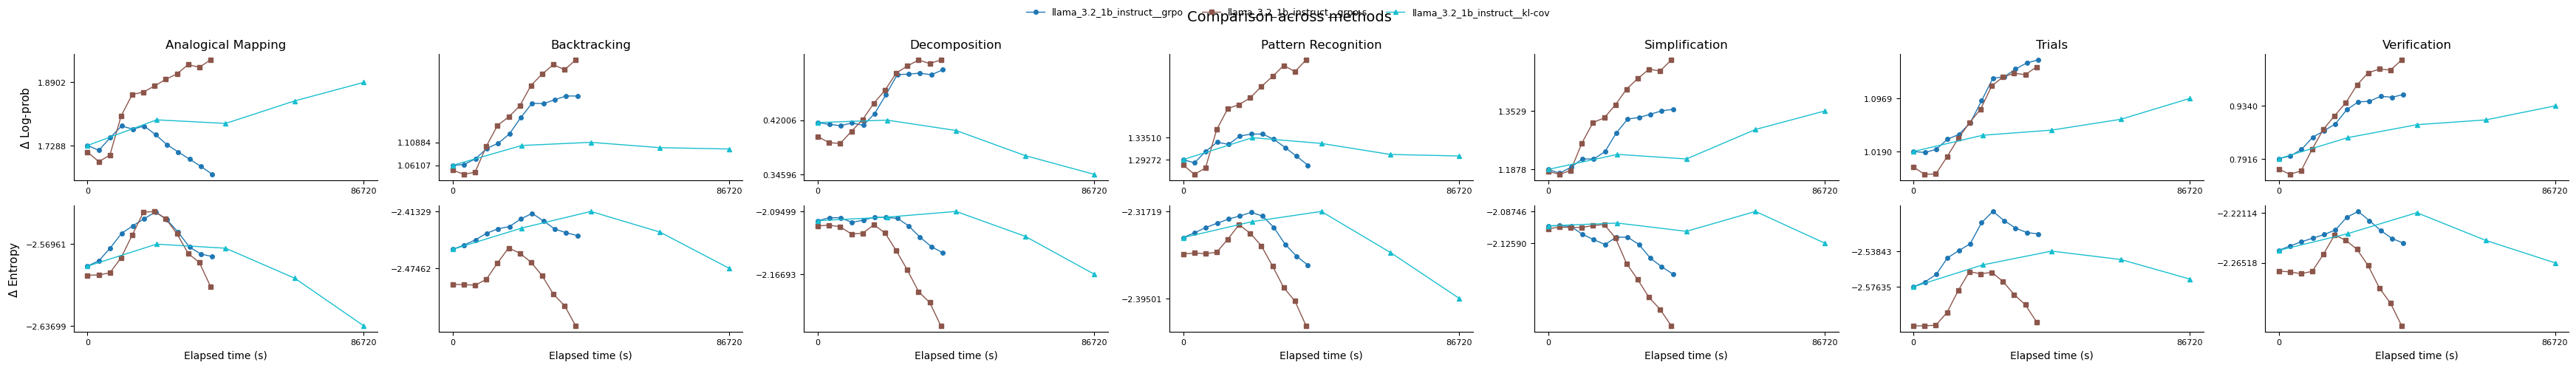

In [17]:
plot(data, timings)

behaviour_types: ['Abductive Reasoning', 'Analogical Reasoning', 'Deductive Reasoning', 'Inductive Reasoning']


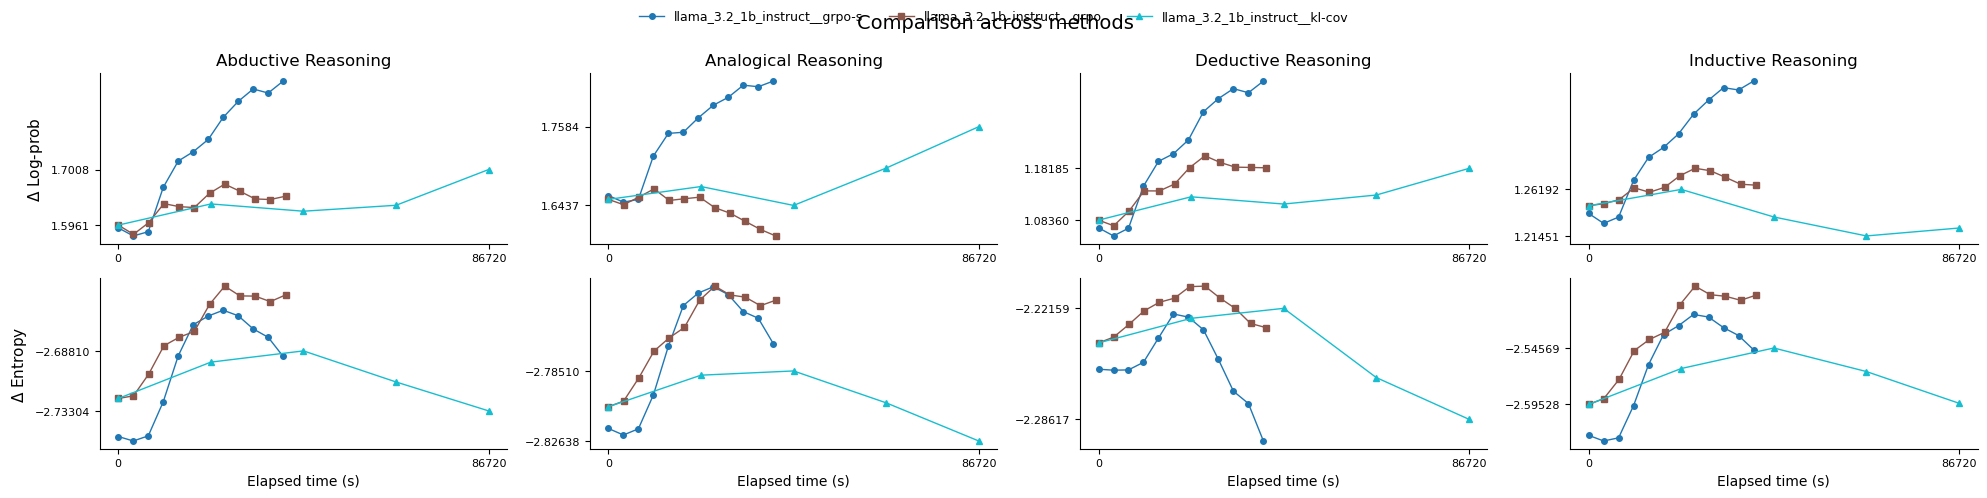

In [18]:
rt_paths_abs = [os.path.join(exp06_path, p) for p in rt_paths]
data = collect_data_new_schema(rt_paths_abs)
plot(data, timings)

### Now implement the bins idea:

Take the data, place likelihoods into bins. Then, plot anew, but this time with bin dimension in plots.

In [28]:
def collect_data_new_schema(paths: list[str]) -> dict:
    """
    Collects data from multiple methods/checkpoints.

    For each checkpoint, it returns:
      - aggregated means per behaviour type (lp and e)
      - a 'raw' DataFrame per checkpoint containing per-example statistics:
            'behaviour_type', 'base_lp', 'lpdelta', 'entdelta'
    """
    per_methods = {}

    for path in paths:
        assert os.path.isdir(path)
        basename = os.path.basename(path)
        method = '__'.join(basename.split('__')[1:]) if '__' in basename else basename

        validation_dir_path = os.path.join(path, 'val_jsonl')
        precomp_files = [f for f in os.listdir(validation_dir_path) if f.endswith('_precomp.jsonl')]
        precomp_files = sorted(precomp_files, key=lambda x: int(x.split("_")[0]))

        checkpoints = []
        for pfile in precomp_files:
            df = pd.read_json(os.path.join(validation_dir_path, pfile), lines=True)

            # Compute per-row means
            df['lpmean'] = df['logprobs'].apply(np.mean)
            df['entmean'] = df['entropy'].apply(np.mean)

            rows = []
            raw_rows = []  # store per-example statistics for binning
            for index, group_df in df.groupby('index'):
                # find anchor
                anchor_row = group_df[group_df['behaviour_type'] == 'anchor']
                other_rows = group_df[group_df['behaviour_type'] != 'anchor']

                # subtract others from anchor
                lpdelta = anchor_row['lpmean'].to_numpy() - other_rows['lpmean'].to_numpy()
                entdelta = anchor_row['lpmean'].to_numpy() - other_rows['entmean'].to_numpy()

                for bt, l, e, base in zip(other_rows['behaviour_type'], lpdelta, entdelta, other_rows['lpmean']):
                    rows.append({'behaviour_type': bt, 'lp': l, 'e': e})
                    raw_rows.append({'behaviour_type': bt, 'base_lp': base, 'lpdelta': l, 'entdelta': e})

            # Create aggregated mean DataFrame
            new_df = pd.DataFrame(rows)
            means: pd.DataFrame = new_df.groupby('behaviour_type').mean()

            # Store checkpoint data with raw info
            checkpoint_data = {
                'lp': means['lp'].to_dict(),
                'e': means['e'].to_dict(),
                'raw': pd.DataFrame(raw_rows)  # needed for binning
            }
            checkpoints.append(checkpoint_data)

        per_methods[method] = checkpoints

    return per_methods

In [54]:
data = collect_data_new_schema(rs_paths_abs)

In [55]:
from typing import Literal

def plot_bin(data: dict, by: Literal['base_likelihood', 'delta'] = 'delta',
             n_bins: int = 3, time_per_step_s: dict[str, int] = None):
    """
    Plot ΔLog-prob per behaviour type, comparing methods, with binning.
    
    Rows = bins, Columns = behaviour types, curves = methods.
    """
    # Collect behaviour types
    behaviour_types = sorted({
        key
        for method_records in data.values()
        for rec in method_records
        for key in rec.get("lp", {}).keys()
    })
    methods = list(data.keys())

    # Prepare binned data and bin labels
    binned_data = {}   # method -> list of DataFrames
    bin_labels = {}    # method -> list of descriptive labels

    for method, records in data.items():
        binned_data[method] = []
        # Concatenate all lpdelta values across records to compute global bins
        all_values = pd.concat([rec["raw"]["lpdelta"] for rec in records if "raw" in rec])
        if all_values.nunique() < n_bins:
            print(f"[plot_bin] Method '{method}' has fewer unique values than n_bins; reducing n_bins.")
            bins = np.unique(all_values)
        else:
            _, bins = pd.qcut(all_values, q=n_bins, retbins=True, duplicates="drop")
        
        # Create descriptive bin labels
        intervals = pd.IntervalIndex.from_breaks(bins)
        desc_map = ["unlikely", "med-likely", "likely"][::-1]
        # Repeat/truncate to match number of intervals
        desc_map = (desc_map * ((len(intervals)//len(desc_map)) + 1))[:len(intervals)]
        bin_labels[method] = [f"{desc_map[i]} ({interval.left:.2f} → {interval.right:.2f})"
                              for i, interval in enumerate(intervals)]

        # Bin each record consistently
        for rec in records:
            if "raw" not in rec:
                continue
            df = rec["raw"].copy()
            df["bin"] = pd.cut(df["lpdelta"], bins=bins, labels=False, include_lowest=True)
            grouped = df.groupby(["behaviour_type", "bin"], observed=False)["lpdelta"].mean().reset_index()
            binned_data[method].append(grouped)

    n_bins_actual = len(bin_labels[methods[0]])
    n_behaviours = len(behaviour_types)

    if n_bins_actual == 0 or n_behaviours == 0:
        print("[plot_bin] ⚠️ No bins or behaviour types found. Check your data.")
        return

    # --- Create figure ---
    fig, axes = plt.subplots(n_bins_actual, n_behaviours,
                             figsize=(5 * n_behaviours, 2.5 * n_bins_actual),
                             squeeze=False)

    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    markers = ['o', 's', '^', 'D', 'x', 'v']

    # --- Plotting ---
    for bi in range(n_bins_actual):
        for col, beh in enumerate(behaviour_types):
            ax = axes[bi, col]
            for method_idx, method in enumerate(methods):
                lp_vals = []
                records = binned_data[method]
                for rec in records:
                    subset = rec[(rec["behaviour_type"] == beh) & (rec["bin"] == bi)]
                    lp_vals.append(subset["lpdelta"].mean() if not subset.empty else np.nan)

                # X-axis
                if time_per_step_s and method in time_per_step_s:
                    step_time = time_per_step_s[method]
                    t = np.arange(len(records)) * step_time
                    xlabel = "Elapsed time (s)"
                else:
                    t = np.arange(len(records))
                    xlabel = "Checkpoint index"

                ax.plot(
                    t, lp_vals,
                    marker=markers[method_idx % len(markers)],
                    color=colors[method_idx],
                    lw=1, markersize=3,
                    label=method
                )

            # Labels
            if col == 0:
                ax.set_ylabel(bin_labels[method][bi], fontsize=9)
            if bi == n_bins_actual - 1:
                ax.set_xlabel(xlabel, fontsize=9)
            if bi == 0:
                ax.set_title(beh, fontsize=12)

    # --- Legend ---
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=9, loc="upper center", ncol=len(methods), frameon=False)
    fig.suptitle(f"ΔLog-prob binned by {by.replace('_',' ')}", fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.93])
    plt.show()

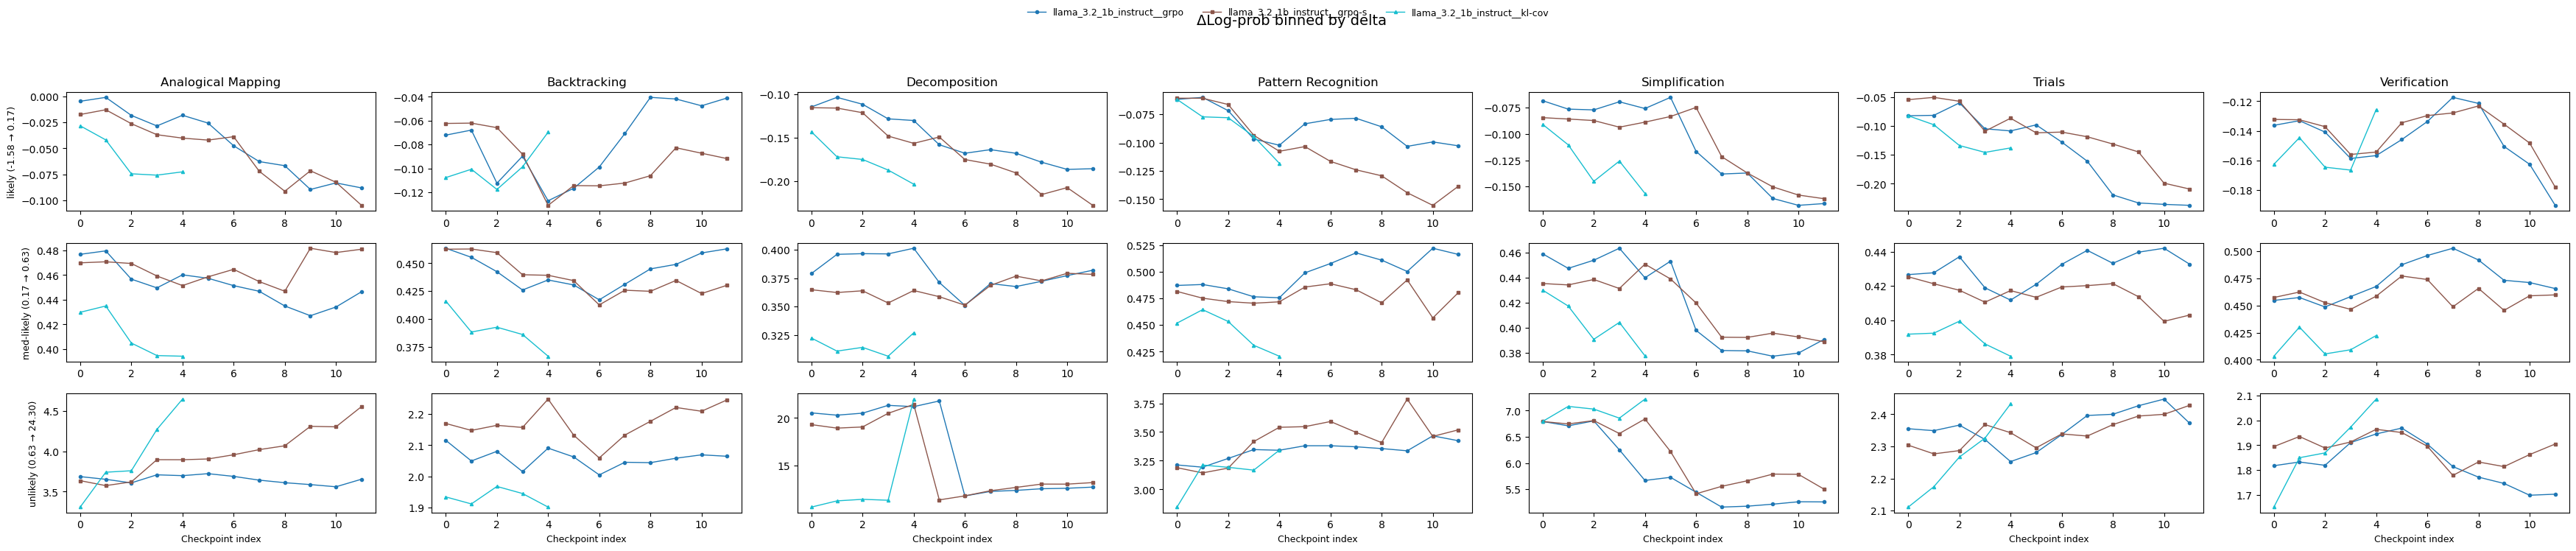

In [56]:
plot_bin(data, by='delta', n_bins=3)